In [55]:
import os
import nd2
import napari
from tifffile import imwrite, imread

from pathlib import Path

from glob import glob

import dask.array as da

from tqdm.notebook import trange, tqdm

import numpy as np
from numpy.fft import rfftn, irfftn, fftshift

import SimpleITK as sitk

from scipy.ndimage import affine_transform, shift, gaussian_filter, convolve

from numba import njit

from scipy.optimize import linear_sum_assignment

In [2]:
path = "/mnt/z/Dasha/2. FAST-AB biosensors/Microscope/Inverted bladder model/TrimFABS sensor 30.06.2026/To analyze"

In [3]:
dead_pixel_mask = imread(os.path.join(path, "pixel-conv.tif"))[0] > 25
mean_values = imread(os.path.join(path, "pixel-mean.tif"))[0]

In [13]:
if True:
    file = "NCCRBM128_sample4.nd2"
    
    files = [
        "NCCRBM128_sample4_before.nd2",
        "NCCRBM128_sample4_TMP.nd2",
    ]
    
    imgs = [
        nd2.ND2File(os.path.join(path, file))
        for file in files
    ]
    
    img_da = da.stack([img.to_dask() for img in imgs], axis=0)
else:
    file = "NCCRBM128_sample5.nd2"
    #file = "NCCRBM128_sample6.nd2"
    
    nd2_file = nd2.ND2File(os.path.join(path, file))
    img_da = nd2_file.to_dask()

In [14]:
def create_pads(offset, img_shape):
    pads0 = [(0, 0)]
    pads1 = [(0, 0)]
    shapes = [img_shape[0], img_shape[2], img_shape[3]]
    for i, o in enumerate(offset):
        if o >= 0:
            pads0.append((0, o))
            pads1.append((o, 0))
        else:
            pads1.append((0, -o))
            pads0.append((-o, 0))
    
    return pads0, pads1

def perc_norm(x, q0=5, q1=95):
    mi, ma = np.percentile(x, q=(q0, q1))
    return (x - mi) / (ma - mi)

def fft_translation(img0, img1):
    fft_img0 = rfftn(img0)
    fft_img1 = rfftn(img1)
    fft_img1_cc = np.conjugate(fft_img1)

    mult = fft_img0 * fft_img1_cc
    mult /= np.abs(mult)
    inverse = irfftn(mult, s=img0.shape, axes=range(img0.ndim))

    inverse_shifted = fftshift(inverse)
    # Offset relative to the center of the array
    peak = np.array(np.unravel_index(np.argmax(inverse_shifted), shape=img0.shape))
    offset = peak - np.array(img0.shape) // 2

    return offset

In [15]:
for i in trange(4):
    img0 = img_da[0, i].compute()
    img1 = img_da[1, i].compute()

    if "sample5" in file and i == 3:
        print("sample5_pos3")
        offset = fft_translation(img0[11:26, 0], img1[:15, 0])
        offset[0] += 11
    elif "sample6" in file and i == 2:
        continue
    elif "sample6" in file and i == 3:
        continue
    else:
        offset = fft_translation(img0[:, 0], img1[:, 0])
    
    np.save(os.path.join(path, "padded-tif-files-offsets", file.replace(".nd2", f"_pos{i}.npy")), offset)

    pads0, pads1 = create_pads(offset, img1.shape)

    x0 = np.pad(img0.transpose(1, 0, 2, 3), pads0, mode="symmetric")
    x1 = np.pad(img1.transpose(1, 0, 2, 3), pads1, mode="symmetric")

    zeros = np.ones((img0.shape[0], img0.shape[2], img0.shape[3]), dtype=bool)
    mask0 = np.pad(zeros, pads0[1:], mode="constant", constant_values=0)
    mask1 = np.pad(zeros, pads1[1:], mode="constant", constant_values=0)

    mask = np.logical_and(mask0, mask1)

    new_img = np.stack([x0, x1], axis=0)

    imwrite(
        os.path.join(path, "padded-tif-files", file.replace(".nd2", f"_pos{i}.tif")),
        new_img,
    )

    imwrite(
        os.path.join(path, "padded-tif-files", file.replace(".nd2", f"_pos{i}_mask.tif")),
        mask,
    )

  0%|          | 0/4 [00:00<?, ?it/s]

In [17]:
def mask_dead_pixels(img, mask):
    weight = np.zeros((3, 3))
    weight[1, 1] = 0
    mean = convolve(img, weight) / weight.sum()
    masked = img.copy()
    masked[mask] = mean[mask]
    return masked

def dead_pixel_values(img, mask):
    weight = np.ones((3, 3))
    weight[1, 1] = 0
    mean = (convolve(img, weight) / weight.sum()).astype(img.dtype)
    return mean[mask]

def mask_dead_pixels_3d(img, mask):
    new = np.copy(img)
    for i in range(len(img)):
        new[i, mask] = dead_pixel_values(img[i], mask)
    return new

In [18]:
def register_3d(img0, img1, spacing, shrink=False, trafo="versor"):
    # Convention: Translation in pixels in (Z, Y, X)
    translation = -fft_translation(img0, img1)
    # Convert to XYZ physical units
    translation_um = translation[::-1] * np.array(spacing[::-1])

    fixed = sitk.GetImageFromArray(img0.astype(np.float32))
    moving = sitk.GetImageFromArray(img1.astype(np.float32))

    fixed.SetSpacing(spacing[::-1])
    moving.SetSpacing(spacing[::-1])

    if trafo == "euler":
        tf = sitk.Euler3DTransform()
    elif trafo == "versor":
        tf = sitk.VersorRigid3DTransform()
    elif trafo == "similarity":
        tf = sitk.Similarity3DTransform()
    elif trafo == "affine":
        tf = sitk.AffineTransform(3)
        
    img_center = np.array(img0.shape[::-1]) * np.array(spacing[::-1]) / 2.0
    tf.SetCenter(img_center.tolist())
    tf.SetTranslation(translation_um.tolist())

    print("translation_um = ", translation_um)

    reg = sitk.ImageRegistrationMethod()
    reg.SetMetricAsCorrelation()
    reg.SetInterpolator(sitk.sitkLinear)
    reg.SetOptimizerAsGradientDescent(
        learningRate=1e-1,
        numberOfIterations=100,
    )
    #reg.SetOptimizerScalesFromIndexShift()
    reg.SetOptimizerScalesFromPhysicalShift()

    if shrink:
        reg.SetShrinkFactorsPerLevel([4, 2, 1]) 
        reg.SetSmoothingSigmasPerLevel([2, 1, 0]) 

    print(fixed.GetSpacing())
    print(moving.GetSpacing())
    
    reg.SetInitialTransform(tf, inPlace=True)
    final_tf = reg.Execute(fixed, moving)
    print("fit is done")
    #result = sitk.Resample(moving, fixed, final_tf, sitk.sitkLinear, np.nan)

    return final_tf

In [19]:
file = "NCCRBM128_sample6.nd2"

nd2_file = nd2.ND2File(os.path.join(path, file))
img_da = nd2_file.to_dask()

/tmp/ipykernel_45752/3456726483.py:3: UserWarning: ND2File file not closed before garbage collection. Please use `with ND2File(...):` context or call `.close()`.
  nd2_file = nd2.ND2File(os.path.join(path, file))


In [33]:
k = 2

img0 = img_da[0, k].compute()
img1 = img_da[1, k].compute()

In [34]:
img0_masked = mask_dead_pixels_3d(img0[:, 0]/mean_values, dead_pixel_mask)
img1_masked = mask_dead_pixels_3d(img1[:, 0]/mean_values, dead_pixel_mask)

In [35]:
trafo = register_3d(img0_masked, img1_masked, spacing=(0.3, 0.17, 0.17))

translation_um =  [-4.42  1.02  0.  ]
(0.17, 0.17, 0.3)
(0.17, 0.17, 0.3)
fit is done


In [91]:
def canvas_bbox(shape0, shape1, R, b):
    """Kleinstes Canvas, das Fixed- und Moving-Bild komplett enthaelt.
    Rueckgabe: (out_shape, lo) mit lo = Fixed-Index des Canvas-Ursprungs."""
    n0 = np.asarray(shape0[-3:], float)
    n1 = np.asarray(shape1[-3:], float)
    corners = np.array([[i, j, k] for i in (0, 1) for j in (0, 1)
                        for k in (0, 1)]) * (n1 - 1)
    warped = corners @ np.asarray(R, float).T + np.asarray(b, float)
    lo = np.floor(np.minimum(warped.min(0), 0.0))
    hi = np.ceil(np.maximum(warped.max(0), n0 - 1))
    return tuple((hi - lo + 1).astype(int)), lo


def pad_to_canvas(img, out_shape, lo, mode="symmetric"):
    lead = img.ndim - 3
    before = (-lo).astype(int)
    pads = [(0, 0)] * lead
    for n, m, bi in zip(img.shape[-3:], out_shape, before):
        pads.append((bi, m - n - bi))
    out = np.pad(img, pads, mode=mode)
    mask = np.pad(np.ones(img.shape[-3:], bool), pads[lead:],
                  mode="constant", constant_values=False)
    return out, mask


def warp_to_canvas(img, out_shape, R, b, lo, order=1, mode="reflect"):
    spatial = img.shape[-3:]
    inv = np.linalg.inv(np.asarray(R, float))
    offset = inv @ (np.asarray(lo, float) - np.asarray(b, float))
    flat = img.reshape((-1,) + spatial)
    out = np.stack([
        affine_transform(v, inv, offset=offset, output_shape=out_shape,
                         order=order, mode=mode) for v in flat
    ]).reshape(img.shape[:-3] + tuple(out_shape))
    mask = affine_transform(np.ones(spatial, np.uint8), inv, offset=offset,
                            output_shape=out_shape, order=0,
                            mode="constant", cval=0).astype(bool)
    return out, mask

def sitk_to_zyx(trafo, shape, spacing, origin=(0, 0, 0), invert=False):
    """SITK-Trafo (physikalisch, xyz) -> (R, tau) fuer warp_to_canvas (Index, zyx).

    shape           : (..., z, y, x) des zu warpenden Bildes
    spacing, origin : wie img.GetSpacing() / img.GetOrigin(), also xyz
    invert          : SITK-Registrierung liefert fixed->moving. Zum Warpen des
                      Moving-Bildes in den Fixed-Frame True setzen.
    """
    A = np.array(trafo.GetMatrix()).reshape(3, 3)
    c = np.array(trafo.GetCenter())
    t = np.array(trafo.GetTranslation())

    if invert:                       # p = A^-1 (p' - c - t) + c
        A = np.linalg.inv(A)
        t = -A @ t

    P = np.eye(3)[::-1]              # xyz -> zyx
    A = P @ A @ P
    c, t = c[::-1], t[::-1]
    o = np.asarray(origin, float)[::-1]

    S = np.diag(np.asarray(spacing, float)[::-1])
    Si = np.linalg.inv(S)

    c_in = (np.asarray(shape[-3:], float) - 1) / 2
    R = Si @ A @ S
    b = Si @ (A @ (o - c) + c + t - o)     # i_fixed = R @ i_moving + b
    return R, b

In [37]:
x0 = img0.transpose(1, 0, 2, 3)
x1 = img1.transpose(1, 0, 2, 3)
shape = x0.shape

spacing = (0.3, 0.17, 0.17)
origin = (0, 0, 0)

R, b = sitk_to_zyx(trafo, shape, spacing[::-1], origin, invert=True)
new_shape, lo = canvas_bbox(shape, shape, R, b)
x0, m0 = pad_to_canvas(x0, new_shape, lo)
x1, m1 = warp_to_canvas(x1, new_shape, R, b, lo)
mask = m0 & m1

In [38]:
np.save(os.path.join(path, "padded-tif-files-offsets", file.replace(".nd2", f"_pos{k}_R.npy")), R)
np.save(os.path.join(path, "padded-tif-files-offsets", file.replace(".nd2", f"_pos{k}_b.npy")), b)

In [39]:
imwrite(
    os.path.join(path, "padded-tif-files", file.replace(".nd2", f"_pos{k}.tif")),
    np.stack([x0, x1], axis=0),
)

imwrite(
    os.path.join(path, "padded-tif-files", file.replace(".nd2", f"_pos{k}_mask.tif")),
    mask,
)

In [92]:
names = ["NCCRBM128_sample4", "NCCRBM128_sample5", "NCCRBM128_sample6"]

for name in names:
    for i in trange(4):
        try:
            offset = np.load(os.path.join(path, "padded-tif-files-offsets", f"{name}_pos{i}.npy"))
        except FileNotFoundError:
            continue
        # for j in [4, 5, 6]:
        for j in [6]:
            lbls = [imread(os.path.join(
                path,
                "sciCORE",
                f"nfmp_prob0.{j}",
                #"2025_12_22_Dasha_ibm-01",
                "2026_01_05_Dasha_ibm-02",
                f"{name}_pos{i}_t{t}_mScarlett.tiff",
            )) for t in range(2)]

            shape = lbls[0].shape
            shape = (shape[0], 0, shape[1], shape[2])
            pads0, pads1 = create_pads(offset, shape)

            x0 = np.pad(lbls[0], pads0[1:], mode="constant")
            x1 = np.pad(lbls[1], pads1[1:], mode="constant")

            imwrite(
                os.path.join(path, "padded-tif-files", f"{name}_pos{i}_new_prob0.{j}.tif"),
                np.stack([x0, x1], axis=0),
            )

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

In [93]:
names = ["NCCRBM128_sample4", "NCCRBM128_sample5", "NCCRBM128_sample6"]

for name in names:
    for i in trange(4):
        try:
            R = np.load(os.path.join(path, "padded-tif-files-offsets", f"{name}_pos{i}_R.npy"))
            b = np.load(os.path.join(path, "padded-tif-files-offsets", f"{name}_pos{i}_b.npy"))
        except FileNotFoundError:
            continue
        # for j in [4, 5, 6]:
        for j in [6]:
            lbls = [imread(os.path.join(
                path,
                "sciCORE",
                f"nfmp_prob0.{j}",
                #"2025_12_22_Dasha_ibm-01",
                "2026_01_05_Dasha_ibm-02",
                f"{name}_pos{i}_t{t}_mScarlett.tiff",
            )) for t in range(2)]

            shape = lbls[0].shape

            new_shape, lo = canvas_bbox(shape, shape, R, b)
            x0, _ = pad_to_canvas(lbls[0], new_shape, lo, mode="constant")
            x1, _ = warp_to_canvas(lbls[1], new_shape, R, b, lo, order=0, mode="constant")

            imwrite(
                os.path.join(path, "padded-tif-files", f"{name}_pos{i}_new_prob0.{j}.tif"),
                np.stack([x0, x1], axis=0),
            )

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

In [64]:
@njit
def label_overlap(x, y):
    x = x.ravel()
    y = y.ravel()
    overlap = np.zeros((1+x.max(),1+y.max()), dtype=np.uint)
    for i in range(len(x)):
        overlap[x[i],y[i]] += 1
    return overlap

def intersection_over_union(overlap):
    if np.sum(overlap) == 0:
        return overlap
    n_pixels_pred = np.sum(overlap, axis=0, keepdims=True)
    n_pixels_true = np.sum(overlap, axis=1, keepdims=True)
    return _safe_divide(overlap, (n_pixels_pred + n_pixels_true - overlap))

def _safe_divide(x,y, eps=1e-10):
    """computes a safe divide which returns 0 if y is zero"""
    if np.isscalar(x) and np.isscalar(y):
        return x/y if np.abs(y)>eps else 0.0
    else:
        out = np.zeros(np.broadcast(x,y).shape, np.float32)
        np.divide(x,y, out=out, where=np.abs(y)>eps)
        return out

In [65]:
overlap = label_overlap(x0, x1)

In [84]:
scores = intersection_over_union(overlap)

scores = scores[1:,1:]
n_true, n_pred = scores.shape
n_matched = min(n_true, n_pred)

thr = 0.1
costs = -(scores >= thr).astype(float) - scores / (2*n_matched)
true_ind, pred_ind = linear_sum_assignment(costs)
assert n_matched == len(true_ind) == len(pred_ind)
match_ok = scores[true_ind, pred_ind] >= thr
tp = np.count_nonzero(match_ok)
tp

np.int64(573)

In [86]:
index0 = 1661

ind = list(true_ind).index(index0-1)
pred_ind[ind] + 1

np.int64(4645)

In [80]:
scores[scores>0]

array([0.05079007, 0.01414141, 0.04256966, ..., 0.00225225, 0.035533  ,
       0.00518135], shape=(3258,), dtype=float32)

<Axes: ylabel='Density'>

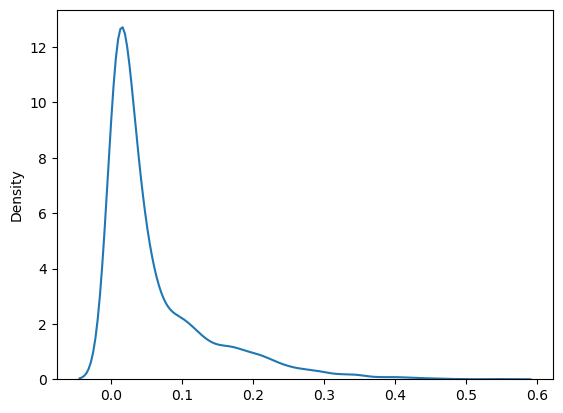

In [81]:
import seaborn as sns

sns.kdeplot(scores[scores>0])